In [2]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import ast
from collections import Counter
from datasets import load_metric
from datasets import Dataset  # Import Dataset from Hugging Face datasets


from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import Trainer, TrainingArguments, DataCollatorForTokenClassification
import torch

In [3]:
df = pd.read_csv("/Users/pin.lyu/Documents/BC_Folder/NLP/Data/complete_data.csv")
df = df.drop(columns=['tokens'])

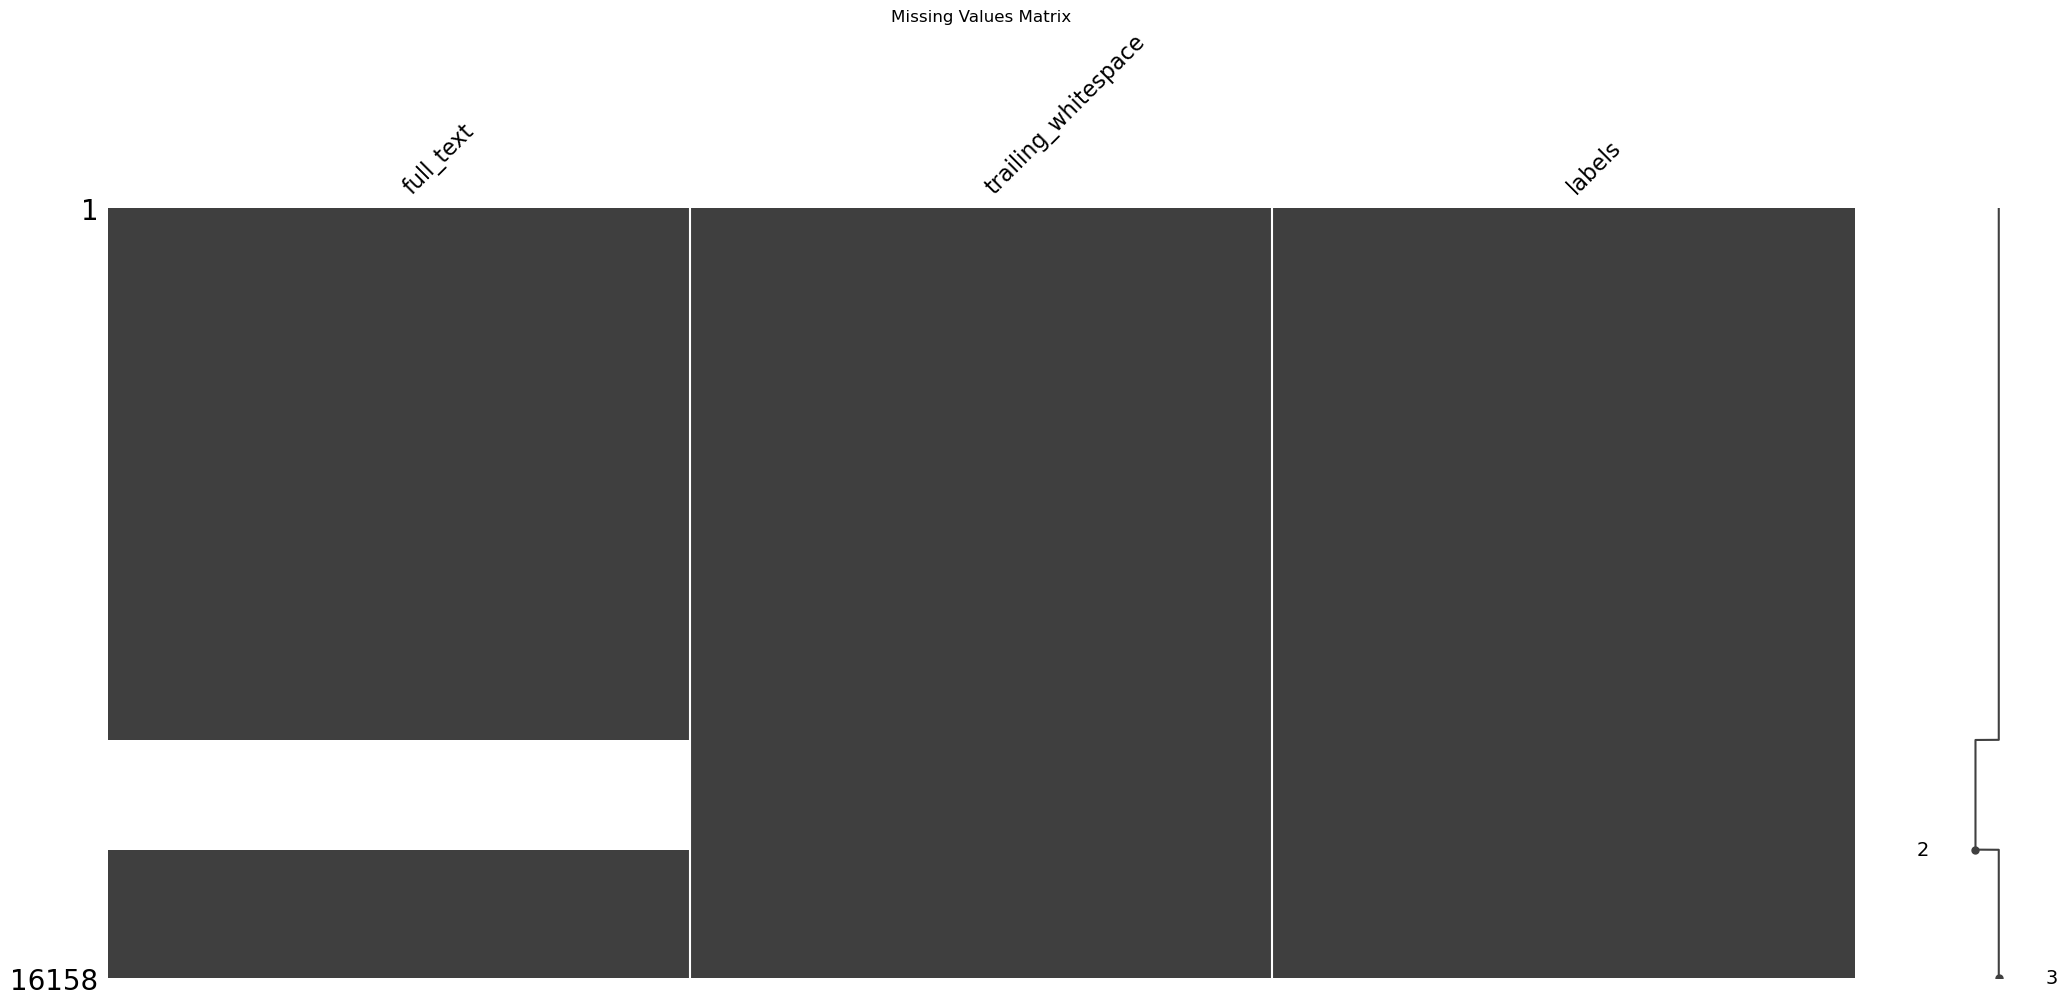

In [4]:
# Matrix visualization
msno.matrix(df)
plt.title('Missing Values Matrix')
plt.show()

In [5]:
# drop missing values in the 'full_text' column

df = df.dropna(subset=['full_text'])

print('The new dataframe dimension is', df.shape)

The new dataframe dimension is (13854, 3)


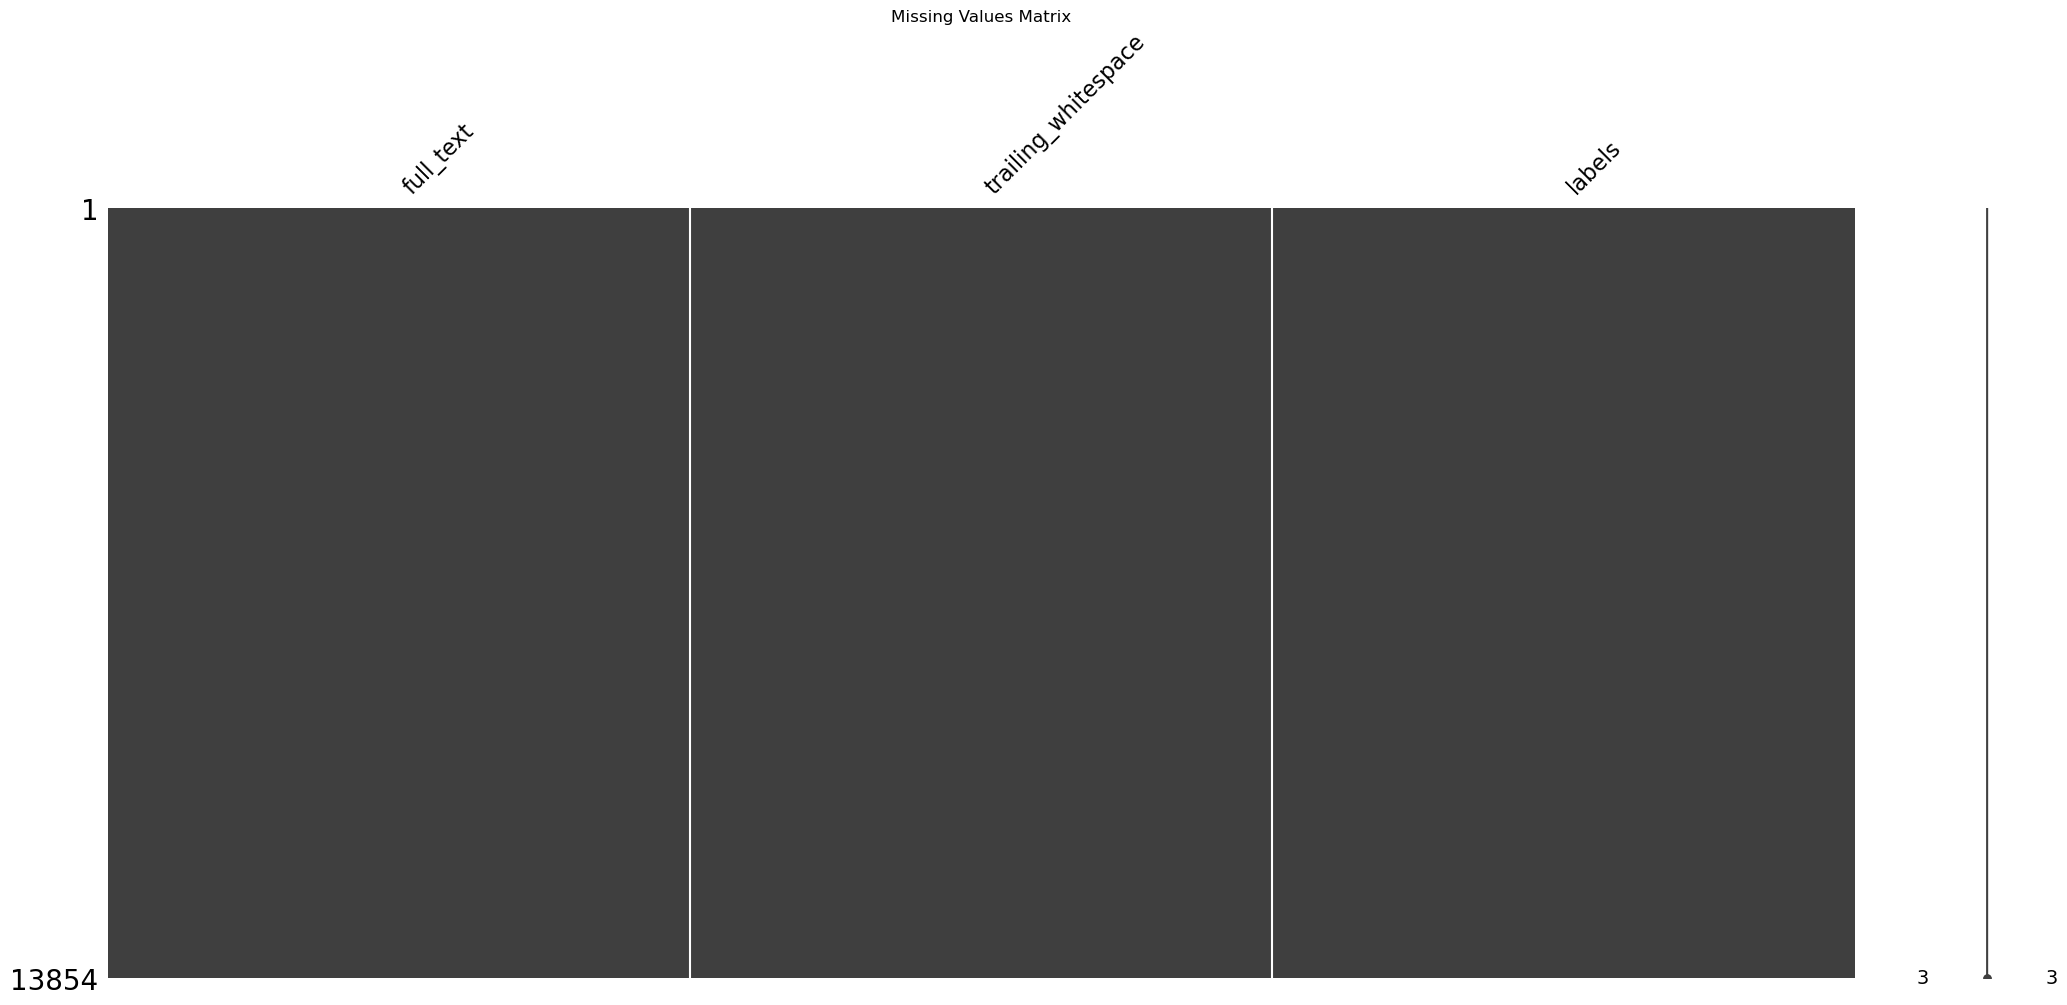

In [6]:
# Matrix visualization
msno.matrix(df)
plt.title('Missing Values Matrix')
plt.show()

In [7]:
# Configuration
MODEL_NAME = "distilbert-base-uncased"
LABEL_LIST = ["O", "B-NAME_STUDENT", "I-NAME_STUDENT", 
              "B-EMAIL", "I-EMAIL", "B-USERNAME", "I-USERNAME",
              "B-ID_NUM", "I-ID_NUM", "B-PHONE_NUM", "I-PHONE_NUM",
              "B-URL_PERSONAL", "I-URL_PERSONAL", 
              "B-STREET_ADDRESS", "I-STREET_ADDRESS"]
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 3

# 1. Data Preparation ----------------------------------------
def prepare_data(df):
    import ast

    def safe_parse(val):
        if isinstance(val, str):
            try:
                return ast.literal_eval(val)
            except:
                return []
        return val

    df['labels'] = df['labels'].apply(safe_parse)
    df['trailing_whitespace'] = df['trailing_whitespace'].apply(safe_parse)

    valid_rows = []
    for i, row in df.iterrows():
        words = row['full_text'].split()
        labels = row['labels']
        whitespace = row['trailing_whitespace']

        # Fix length issues
        if len(labels) > len(words):
            labels = labels[:len(words)]
        if len(whitespace) > len(words):
            whitespace = whitespace[:len(words)]

        if len(words) == len(labels) == len(whitespace):
            row['labels'] = labels
            row['trailing_whitespace'] = whitespace
            valid_rows.append(row)
        else:
            print(f"⚠️ Skipping row {i}: mismatch remains after trimming")

    return pd.DataFrame(valid_rows)


# 2. Model Class --------------------------------------------
class PIIDetectionModel:
    def __init__(self, model_name=MODEL_NAME, label_list=LABEL_LIST):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, add_prefix_space=True)
        self.label_list = label_list
        self.model = AutoModelForTokenClassification.from_pretrained(
            model_name,
            num_labels=len(label_list),
            id2label={i: label for i, label in enumerate(label_list)},
            label2id={label: i for i, label in enumerate(label_list)}
        )
    
    def tokenize(self, examples):
        """Tokenize and align labels with tokens (return plain lists)"""
        tokenized_inputs = self.tokenizer(
            examples["full_text"],
            truncation=True,
            is_split_into_words=False,
            max_length=MAX_LENGTH,
            padding="max_length",
        )
        labels = []
        for i in range(len(examples["full_text"])):
            word_ids = tokenized_inputs.word_ids(batch_index=i)
            label_ids = []
            previous_word_idx = None
            for word_idx in word_ids:
                if word_idx is None:
                    label_ids.append(-100)
                elif word_idx != previous_word_idx:
                    try:
                        label_ids.append(self.label_list.index(examples["labels"][i][word_idx]))
                    except (IndexError, ValueError):
                        label_ids.append(-100)
                else:
                    label_ids.append(-100)
                previous_word_idx = word_idx
            labels.append(label_ids)
        tokenized_inputs["labels"] = labels  # Keep as list, not tensor
        return tokenized_inputs

# 3. Metrics ------------------------------------------------
def compute_metrics(p):
    metric = load_metric("seqeval")
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [
        [LABEL_LIST[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [LABEL_LIST[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# 4. Training Pipeline --------------------------------------
def train_pii_model(df, output_dir="./pii_model"):
    df = prepare_data(df)
    train_df, eval_df = train_test_split(df, test_size=0.2)
    train_ds = Dataset.from_pandas(train_df)
    eval_ds = Dataset.from_pandas(eval_df)
    model = PIIDetectionModel()
    tokenized_train = train_ds.map(model.tokenize, batched=True)
    tokenized_eval = eval_ds.map(model.tokenize, batched=True)
    args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_dir='./logs',
    )
    data_collator = DataCollatorForTokenClassification(model.tokenizer)
    trainer = Trainer(
        model=model.model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_eval,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    trainer.save_model(output_dir)
    model.tokenizer.save_pretrained(output_dir)
    return trainer

# 5. Prediction Pipeline ------------------------------------
class PIIPredictor:
    def __init__(self, model_path):
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForTokenClassification.from_pretrained(model_path)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
    
    def predict(self, text):
        tokenized = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length",
            return_offsets_mapping=True,
            return_special_tokens_mask=True
        )
        word_ids = tokenized.word_ids()
        inputs = {k: v.to(self.device) for k, v in tokenized.items() if k in ["input_ids", "attention_mask"]}
        with torch.no_grad():
            outputs = self.model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=2)[0].cpu().numpy()
        tokens = self.tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
        previous_word_idx = None
        results = []
        for i, (token, pred_idx) in enumerate(zip(tokens, predictions)):
            word_idx = word_ids[i]
            if word_idx is None or word_idx == previous_word_idx:
                continue
            results.append((token, LABEL_LIST[pred_idx]))
            previous_word_idx = word_idx
        return results

# Usage Example
if __name__ == "__main__":
    #df = pd.read_csv("your_data.csv")  # Ensure this has full_text, labels, trailing_whitespace
    trainer = train_pii_model(df)
    predictor = PIIPredictor("./pii_model")
    sample_text = "Contact John Doe at john@email.com or 555-123-4567"
    print("Prediction for:", sample_text)
    print(predictor.predict(sample_text))


⚠️ Skipping row 6: mismatch remains after trimming
⚠️ Skipping row 18: mismatch remains after trimming
⚠️ Skipping row 23: mismatch remains after trimming
⚠️ Skipping row 26: mismatch remains after trimming
⚠️ Skipping row 32: mismatch remains after trimming
⚠️ Skipping row 37: mismatch remains after trimming
⚠️ Skipping row 50: mismatch remains after trimming
⚠️ Skipping row 62: mismatch remains after trimming
⚠️ Skipping row 64: mismatch remains after trimming
⚠️ Skipping row 70: mismatch remains after trimming
⚠️ Skipping row 73: mismatch remains after trimming
⚠️ Skipping row 87: mismatch remains after trimming
⚠️ Skipping row 104: mismatch remains after trimming
⚠️ Skipping row 105: mismatch remains after trimming
⚠️ Skipping row 106: mismatch remains after trimming
⚠️ Skipping row 107: mismatch remains after trimming
⚠️ Skipping row 109: mismatch remains after trimming
⚠️ Skipping row 114: mismatch remains after trimming
⚠️ Skipping row 119: mismatch remains after trimming
⚠️ Ski

/Applications/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Parameter 'function'=<bound method PIIDetectionModel.tokenize of <__main__.PIIDetectionModel object at 0x3169c3080>> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the c

  0%|          | 0/2043 [00:00<?, ?it/s]/Applications/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:685: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 24%|██▍       | 500/2043 [05:22<17:35,  1.46it/s]

{'loss': 0.1301, 'grad_norm': 0.22279922664165497, 'learning_rate': 1.5105237395986297e-05, 'epoch': 0.73}


                                                  
 33%|███▎      | 681/2043 [08:01<14:57,  1.52it/s]

...

{'loss': 0.0539, 'grad_norm': 0.680016815662384, 'learning_rate': 4.209495839451787e-07, 'epoch': 2.94}


                                                   
100%|██████████| 2043/2043 [48:36<00:00,  1.75it/s]

{'eval_loss': 0.055280670523643494, 'eval_precision': 0.6060120240480962, 'eval_recall': 0.28245843452269753, 'eval_f1': 0.38532110091743116, 'eval_accuracy': 0.9829815286942611, 'eval_runtime': 34.5534, 'eval_samples_per_second': 78.806, 'eval_steps_per_second': 4.949, 'epoch': 3.0}


100%|██████████| 2043/2043 [48:38<00:00,  1.43s/it]


{'train_runtime': 2920.5996, 'train_samples_per_second': 11.188, 'train_steps_per_second': 0.7, 'train_loss': 0.07617466751991156, 'epoch': 3.0}
Prediction for: Contact John Doe at john@email.com or 555-123-4567
[('contact', 'O'), ('john', 'O'), ('doe', 'O'), ('at', 'O'), ('john', 'O'), ('@', 'O'), ('email', 'B-PHONE_NUM'), ('.', 'I-PHONE_NUM'), ('com', 'I-PHONE_NUM'), ('or', 'I-PHONE_NUM'), ('555', 'I-PHONE_NUM'), ('-', 'I-PHONE_NUM'), ('123', 'I-PHONE_NUM'), ('-', 'I-PHONE_NUM'), ('45', 'I-PHONE_NUM')]


In [ ]:
for i, row in df.iterrows():
    text_words = row['full_text'].split()
    if len(text_words) != len(row['labels']) or len(text_words) != len(row['trailing_whitespace']):
        print(f"\n❌ Row {i} mismatch:")
        print("Text:", row['full_text'])
        print("Words:", text_words)
        print("Labels:", row['labels'])
        print("Whitespace:", row['trailing_whitespace'])
        print("Word count:", len(text_words))
        print("Label count:", len(row['labels']))
        print("Whitespace count:", len(row['trailing_whitespace']))
        raise AssertionError(f"Length mismatch in row {i}")


In [ ]:
df['labels'] = df['labels'].apply(ast.literal_eval)  # Convert string to list

In [ ]:
from collections import Counter

# Assuming df['labels'] contains lists of labels
all_labels = [label for sublist in df['labels'] for label in sublist]
label_counts = Counter(all_labels)

# Convert to DataFrame for better display
label_df = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count']).sort_values('count', ascending=False)

print("Complete Label Distribution:")
print(label_df)

Class imbalance exist